# 08 Compare WLASL1000 Experiments

## Purpose
This notebook compares all WLASL1000 experiments:

- V1 BiGRU + Temporal Attention
- Light V2 BiGRU + Attention
- Small Transformer Encoder

Use this before deciding whether to move to WLASL2000.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Set paths

In [3]:
PROJECT_ROOT = Path("E:/Be_My_Ear")
DATASET_NAME = "WLASL1000"
PREFIX = "wlasl1000"

MODEL_DIR = PROJECT_ROOT / "models" / "ASL" / DATASET_NAME
REPORT_DIR = PROJECT_ROOT / "reports" / f"phase1_{PREFIX}"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Model folder:", MODEL_DIR)
print("Report folder:", REPORT_DIR)

Model folder: E:\Be_My_Ear\models\ASL\WLASL1000
Report folder: E:\Be_My_Ear\reports\phase1_wlasl1000


## 2. Load model result summaries

In [4]:
result_files = [
    MODEL_DIR / f"bigru_attention_{PREFIX}_result_summary.csv",
    MODEL_DIR / f"bigru_attention_light_v2_{PREFIX}_result_summary.csv",
    MODEL_DIR / f"transformer_encoder_{PREFIX}_result_summary.csv",
]

rows = []

for file in result_files:
    if file.exists():
        temp = pd.read_csv(file)
        if len(temp) > 0:
            row = temp.iloc[0].to_dict()
            row["source_file"] = str(file)
            rows.append(row)
    else:
        print("Missing:", file)

comparison_df = pd.DataFrame(rows)

if len(comparison_df) == 0:
    raise FileNotFoundError("No WLASL1000 result files found.")

comparison_df

,dataset,model,clean_samples,classes,input_shape,velocity_features,best_val_f1,best_val_top5,checkpoint_epoch,test_top1_accuracy,test_top3_accuracy,test_top5_accuracy,test_macro_f1,model_path,history_path,source_file,features,norm_stats_path
0,WLASL1000,BiGRU + Temporal Attention,7232,1000,"(60, 516)",True,0.170589,0.463393,42,0.208036,0.388393,0.463393,0.167371,E:\Be_My_Ear\models\ASL\WLASL1000\bigru_attent...,E:\Be_My_Ear\models\ASL\WLASL1000\bigru_attent...,E:\Be_My_Ear\models\ASL\WLASL1000\bigru_attent...,NaN,NaN
1,WLASL1000,BiGRU + Attention Light V2,7232,1000,"(60, 516)",NaN,0.197183,0.519022,62,0.243659,0.434783,0.510870,0.198214,E:\Be_My_Ear\models\ASL\WLASL1000\bigru_attent...,E:\Be_My_Ear\models\ASL\WLASL1000\bigru_attent...,E:\Be_My_Ear\models\ASL\WLASL1000\bigru_attent...,keypoints + velocity,E:\Be_My_Ear\models\ASL\WLASL1000\wlasl1000_li...
2,WLASL1000,Small Transformer Encoder,7232,1000,"(60, 516)",NaN,0.188702,0.500000,59,0.221014,0.400362,0.489130,0.166631,E:\Be_My_Ear\models\ASL\WLASL1000\transformer_...,E:\Be_My_Ear\models\ASL\WLASL1000\transformer_...,E:\Be_My_Ear\models\ASL\WLASL1000\transformer_...,keypoints + velocity,E:\Be_My_Ear\models\ASL\WLASL1000\wlasl1000_tr...


## 3. Create clean comparison table

In [5]:
columns = [
    "dataset", "model", "clean_samples", "classes", "input_shape",
    "test_top1_accuracy", "test_top3_accuracy", "test_top5_accuracy",
    "test_macro_f1", "best_val_f1", "best_val_top5", "checkpoint_epoch",
    "source_file"
]

available_columns = [c for c in columns if c in comparison_df.columns]
clean_df = comparison_df[available_columns].copy()

metric_cols = [
    "test_top1_accuracy", "test_top3_accuracy", "test_top5_accuracy",
    "test_macro_f1", "best_val_f1", "best_val_top5"
]

for col in metric_cols:
    if col in clean_df.columns:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

clean_df = clean_df.sort_values("test_top1_accuracy", ascending=False)

comparison_file = REPORT_DIR / f"{PREFIX}_all_model_comparison.csv"
clean_df.to_csv(comparison_file, index=False)

print("Saved comparison:", comparison_file)
clean_df

Saved comparison: E:\Be_My_Ear\reports\phase1_wlasl1000\wlasl1000_all_model_comparison.csv


,dataset,model,clean_samples,classes,input_shape,test_top1_accuracy,test_top3_accuracy,test_top5_accuracy,test_macro_f1,best_val_f1,best_val_top5,checkpoint_epoch,source_file
1,WLASL1000,BiGRU + Attention Light V2,7232,1000,"(60, 516)",0.243659,0.434783,0.510870,0.198214,0.197183,0.519022,62,E:\Be_My_Ear\models\ASL\WLASL1000\bigru_attent...
2,WLASL1000,Small Transformer Encoder,7232,1000,"(60, 516)",0.221014,0.400362,0.489130,0.166631,0.188702,0.500000,59,E:\Be_My_Ear\models\ASL\WLASL1000\transformer_...
0,WLASL1000,BiGRU + Temporal Attention,7232,1000,"(60, 516)",0.208036,0.388393,0.463393,0.167371,0.170589,0.463393,42,E:\Be_My_Ear\models\ASL\WLASL1000\bigru_attent...


## 4. Plot Top-1 / Top-3 / Top-5 accuracy

<Figure size 1000x500 with 0 Axes>

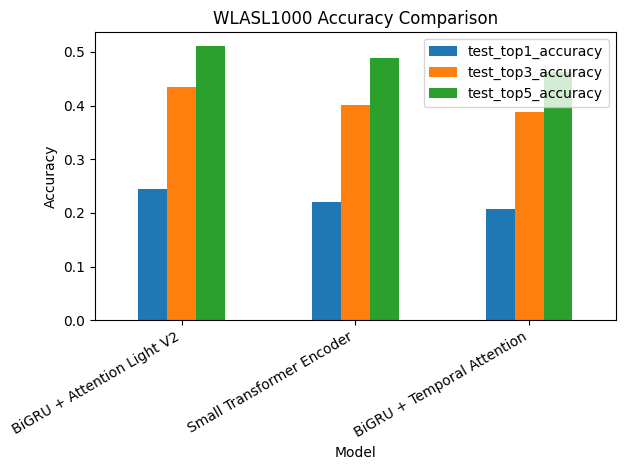

In [6]:
plot_df = clean_df.set_index("model")

plt.figure(figsize=(10, 5))
plot_df[["test_top1_accuracy", "test_top3_accuracy", "test_top5_accuracy"]].plot(kind="bar")
plt.title("WLASL1000 Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. Plot Macro F1

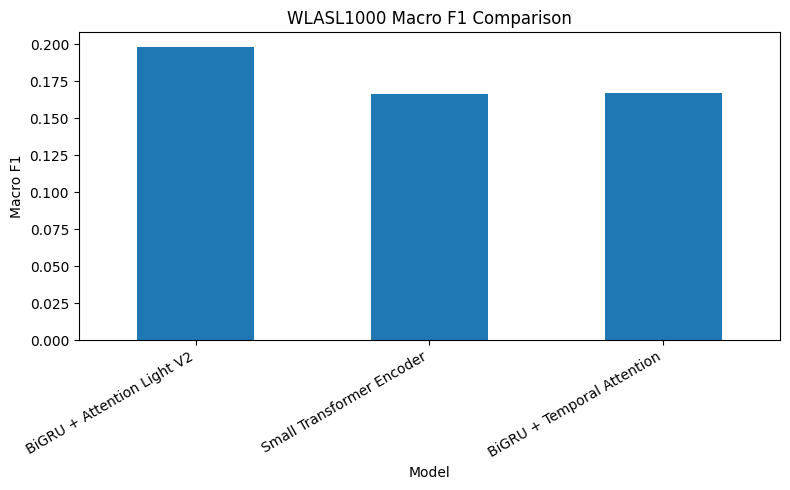

In [7]:
plt.figure(figsize=(8, 5))
plot_df["test_macro_f1"].plot(kind="bar")
plt.title("WLASL1000 Macro F1 Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 6. Load confidence threshold reports

In [8]:
threshold_files = {
    "V1 BiGRU": REPORT_DIR / f"{PREFIX}_confidence_threshold_analysis.csv",
    "Light V2 BiGRU": REPORT_DIR / f"bigru_attention_light_v2_{PREFIX}_confidence_threshold_analysis.csv",
    "Transformer": REPORT_DIR / f"transformer_encoder_{PREFIX}_confidence_threshold_analysis.csv",
}

threshold_rows = []

for model_name, file in threshold_files.items():
    if file.exists():
        temp = pd.read_csv(file)
        temp["model"] = model_name
        threshold_rows.append(temp)
    else:
        print("Missing threshold file:", file)

if threshold_rows:
    threshold_df = pd.concat(threshold_rows, ignore_index=True)
    threshold_file = REPORT_DIR / f"{PREFIX}_confidence_threshold_model_comparison.csv"
    threshold_df.to_csv(threshold_file, index=False)
    print("Saved threshold comparison:", threshold_file)
    display(threshold_df.head())
else:
    threshold_df = pd.DataFrame()
    print("No threshold reports found yet.")

Saved threshold comparison: E:\Be_My_Ear\reports\phase1_wlasl1000\wlasl1000_confidence_threshold_model_comparison.csv


,confidence_threshold,coverage,top1_accuracy_on_confident_samples,top5_accuracy_on_confident_samples,num_confident_samples,model
0,0.2,0.752717,0.245487,0.516245,831,V1 BiGRU
1,0.3,0.525362,0.281034,0.537931,580,V1 BiGRU
2,0.4,0.381341,0.334917,0.593824,421,V1 BiGRU
3,0.5,0.270833,0.347826,0.608696,299,V1 BiGRU
4,0.6,0.199275,0.381818,0.618182,220,V1 BiGRU


## 7. Compare important confidence thresholds

In [9]:
if len(threshold_df) > 0:
    key_thresholds = threshold_df[threshold_df["confidence_threshold"].isin([0.5, 0.7])].copy()
    key_thresholds = key_thresholds[
        [
            "model",
            "confidence_threshold",
            "coverage",
            "top1_accuracy_on_confident_samples",
            "top5_accuracy_on_confident_samples",
            "num_confident_samples"
        ]
    ]
    key_thresholds = key_thresholds.sort_values(
        ["confidence_threshold", "top1_accuracy_on_confident_samples"],
        ascending=[True, False]
    )

    key_file = REPORT_DIR / f"{PREFIX}_key_threshold_comparison.csv"
    key_thresholds.to_csv(key_file, index=False)
    print("Saved key threshold comparison:", key_file)
    display(key_thresholds)
else:
    print("No threshold comparison available.")

Saved key threshold comparison: E:\Be_My_Ear\reports\phase1_wlasl1000\wlasl1000_key_threshold_comparison.csv


,model,confidence_threshold,coverage,top1_accuracy_on_confident_samples,top5_accuracy_on_confident_samples,num_confident_samples
11,Light V2 BiGRU,0.5,0.232790,0.396887,0.696498,257
19,Transformer,0.5,0.255435,0.386525,0.670213,282
3,V1 BiGRU,0.5,0.270833,0.347826,0.608696,299
21,Transformer,0.7,0.116848,0.457364,0.720930,129
5,V1 BiGRU,0.7,0.130435,0.451389,0.680556,144
13,Light V2 BiGRU,0.7,0.127717,0.446809,0.744681,141


## 8. Decision recommendation

In [10]:
best_top1 = clean_df.sort_values("test_top1_accuracy", ascending=False).iloc[0]
best_top5 = clean_df.sort_values("test_top5_accuracy", ascending=False).iloc[0]
best_f1 = clean_df.sort_values("test_macro_f1", ascending=False).iloc[0]

print("WLASL1000 model selection summary")
print("---------------------------------")
print("Best Top-1 model:", best_top1["model"], "|", round(best_top1["test_top1_accuracy"], 4))
print("Best Top-5 model:", best_top5["model"], "|", round(best_top5["test_top5_accuracy"], 4))
print("Best Macro F1 model:", best_f1["model"], "|", round(best_f1["test_macro_f1"], 4))

if best_top1["model"] == best_f1["model"]:
    print("\nRecommended selected model:", best_top1["model"])
else:
    print("\nTop-1 and Macro F1 disagree.")
    print("For the app, prioritise Top-1 + confidence threshold reliability.")
    print("For academic model balance, prioritise Macro F1.")

WLASL1000 model selection summary
---------------------------------
Best Top-1 model: BiGRU + Attention Light V2 | 0.2437
Best Top-5 model: BiGRU + Attention Light V2 | 0.5109
Best Macro F1 model: BiGRU + Attention Light V2 | 0.1982

Recommended selected model: BiGRU + Attention Light V2
